In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# =========================
# LOAD DATA
# =========================
data = pd.read_csv(r"C:\Users\arush\OneDrive\Desktop\EMG\5 Sensor\emg_dataset_features.csv")

X = data.iloc[:, :-1].values   # features
y = data.iloc[:, -1].values    # labels

# =========================
# SPLIT FIRST (avoid leakage)
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================
# NORMALIZATION
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

joblib.dump(scaler, "scaler.pkl")

# =========================
# RESHAPE → (samples, 5, 6, 1)
# =========================
X_train = X_train.reshape(-1, 5, 6, 1)
X_test  = X_test.reshape(-1, 5, 6, 1)

# =========================
# MODEL
# =========================
model = Sequential([

    Conv2D(32, (2,2), activation='relu', input_shape=(5,6,1)),
    BatchNormalization(),

    Conv2D(64, (2,2), activation='relu'),
    BatchNormalization(),

    MaxPooling2D((1,2)),
    Dropout(0.3),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(64, activation='relu'),

    Dense(9, activation='softmax')  # 9 gestures
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# CALLBACKS
# =========================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

# =========================
# TRAIN
# =========================
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

# =========================
# EVALUATION
# =========================
loss, accuracy = model.evaluate(X_test, y_test)
print("\nFinal Test Accuracy:", accuracy)

# =========================  
# PREDICTIONS
# =========================
y_pred = np.argmax(model.predict(X_test), axis=1)


# =========================
# SAVE MODEL
# =========================
model.save("emg_cnn_model.h5")

print("\n✅ Model and scaler saved successfully!")

Epoch 1/100


C:\Users\arush\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3725 - loss: 1.9735 - val_accuracy: 0.5599 - val_loss: 1.8446 - learning_rate: 0.0010
Epoch 2/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6455 - loss: 1.0466 - val_accuracy: 0.7018 - val_loss: 1.3441 - learning_rate: 0.0010
Epoch 3/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7613 - loss: 0.7605 - val_accuracy: 0.7630 - val_loss: 0.8744 - learning_rate: 0.0010
Epoch 4/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7599 - loss: 0.6873 - val_accuracy: 0.8177 - val_loss: 0.5852 - learning_rate: 0.0010
Epoch 5/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7894 - loss: 0.5972 - val_accuracy: 0.8516 - val_loss: 0.4919 - learning_rate: 0.0010
Epoch 6/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8133 - loss: 0.5554 - val_accuracy: 0.8750 - val_loss: 0.4310 - learning_rate: 0.0010
Epoch 7/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8227 - loss: 0.5426 - val_accuracy: 0.876


✅ Model and scaler saved successfully!


In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# y_test → true labels
# y_pred → predicted labels

# =========================
# BASIC METRICS
# =========================
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8739583333333333
Precision: 0.8747257118223433
Recall   : 0.8739583333333333
F1 Score : 0.8738823031472971


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


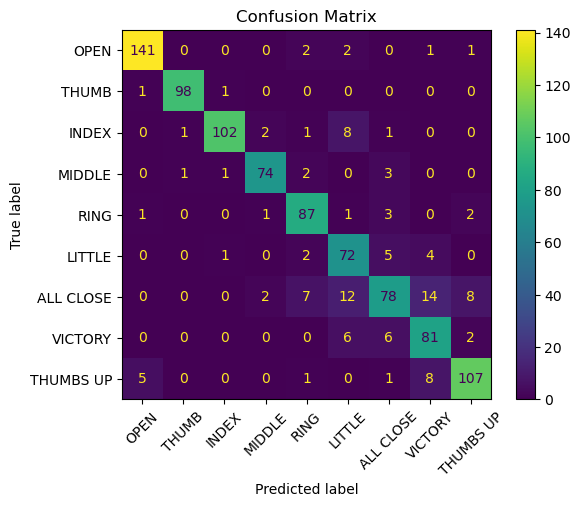

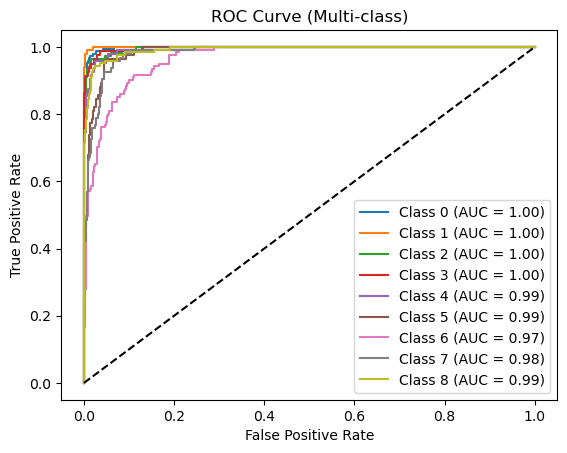

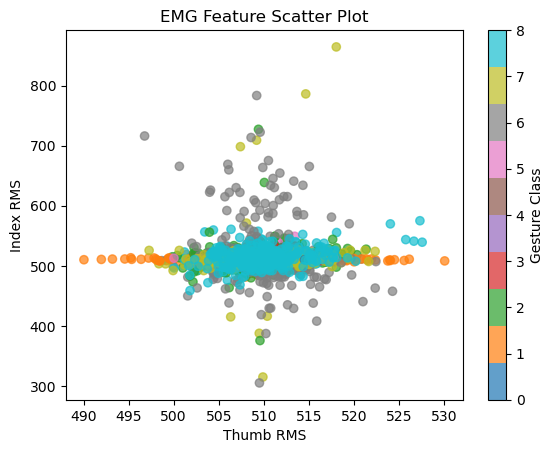

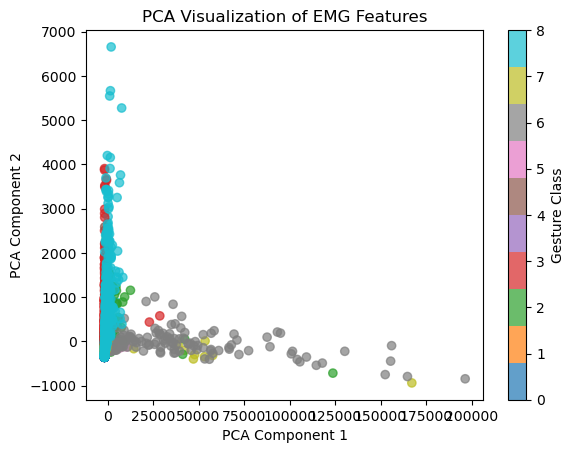

In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# =========================
# PREDICTIONS
# =========================
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# =========================
# CONFUSION MATRIX (PLOT)
# =========================
cm = confusion_matrix(y_test, y_pred)

labels = [
    "OPEN","THUMB","INDEX","MIDDLE",
    "RING","LITTLE","ALL CLOSE","VICTORY","THUMBS UP"
]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=45)

plt.title("Confusion Matrix")
plt.show()

# =========================
# ROC CURVE (MULTI-CLASS)
# =========================
y_test_bin = label_binarize(y_test, classes=np.arange(9))

plt.figure()

for i in range(9):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.legend()
plt.show()

# =========================
# FEATURE SCATTER (RMS)
# =========================
thumb_rms  = X[:, 0]
index_rms  = X[:, 6]
middle_rms = X[:, 12]

plt.scatter(thumb_rms, index_rms, c=y, cmap='tab10', alpha=0.7)

plt.xlabel("Thumb RMS")
plt.ylabel("Index RMS")
plt.title("EMG Feature Scatter Plot")
plt.colorbar(label="Gesture Class")
plt.show()

# =========================
# PCA VISUALIZATION
# =========================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.reshape(X.shape[0], -1))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.7)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Visualization of EMG Features")
plt.colorbar(label="Gesture Class")
plt.show()